# EDA

### Imports

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
plt.style.use("default")
sns.set_theme(style="whitegrid")

### ML

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

# Scaling
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

# Models
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

In [30]:
### Evaluation Metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    RocCurveDisplay,
    classification_report,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [31]:
from pathlib import Path

raw_data = Path("../data/raw")
processed_data = Path("../data/processed")

raw_data.mkdir(parents=True, exist_ok=True)
processed_data.mkdir(parents=True, exist_ok=True)

### Import Data From Kaggle

In [32]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dileep070/heart-disease-prediction-using-logistic-regression")

print("Path to dataset files:", path)

Path to dataset files: /Users/gracescanlan/.cache/kagglehub/datasets/dileep070/heart-disease-prediction-using-logistic-regression/versions/1


In [33]:
import os

print(path)
print(os.listdir(path))

/Users/gracescanlan/.cache/kagglehub/datasets/dileep070/heart-disease-prediction-using-logistic-regression/versions/1
['framingham.csv']


In [34]:
import shutil
from pathlib import Path

source_file = Path(path) / "framingham.csv"
destination_file = raw_data / "framingham.csv"

shutil.copy(source_file, destination_file)

print("Dataset copied to:")
print(destination_file.resolve())

Dataset copied to:
/Volumes/GraceHardDrive/aml_final_project/data/raw/framingham.csv


In [35]:
df = pd.read_csv("../data/raw/framingham.csv")

## Dataset Overview

### Shape

In [36]:
df.shape

(4238, 16)

### Column names

In [37]:
df.columns

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='object')

### Data Types

In [38]:
df.dtypes

male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

### General Information

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


### Summary Statistics

In [40]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


### Missing Values

In [41]:
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

### Visualization

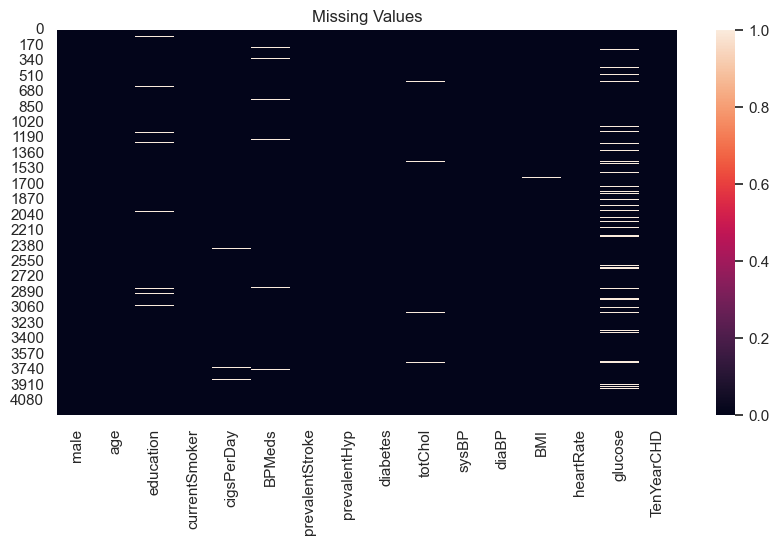

In [42]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull())
plt.title("Missing Values")
plt.show()

### Duplicate Rows

In [43]:
df.duplicated().sum()

0

## Target Variable

In [44]:
df["TenYearCHD"].value_counts()

TenYearCHD
0    3594
1     644
Name: count, dtype: int64

### Percentage

In [45]:
df["TenYearCHD"].value_counts(normalize=True)

TenYearCHD
0    0.848042
1    0.151958
Name: proportion, dtype: float64

### Bar Plot

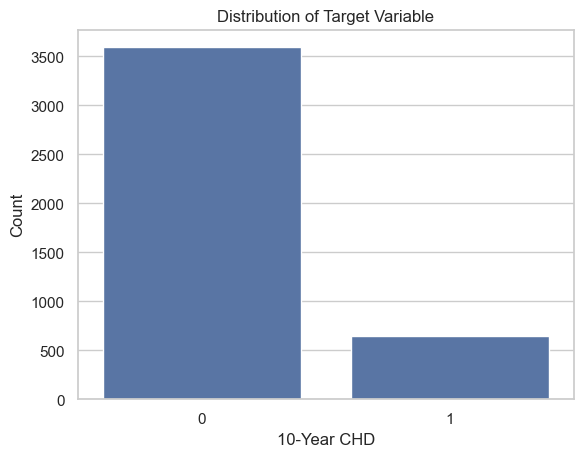

In [46]:
sns.countplot(data=df, x="TenYearCHD")

plt.title("Distribution of Target Variable")
plt.xlabel("10-Year CHD")
plt.ylabel("Count")

plt.show()

### Distribution of Numerical Variables

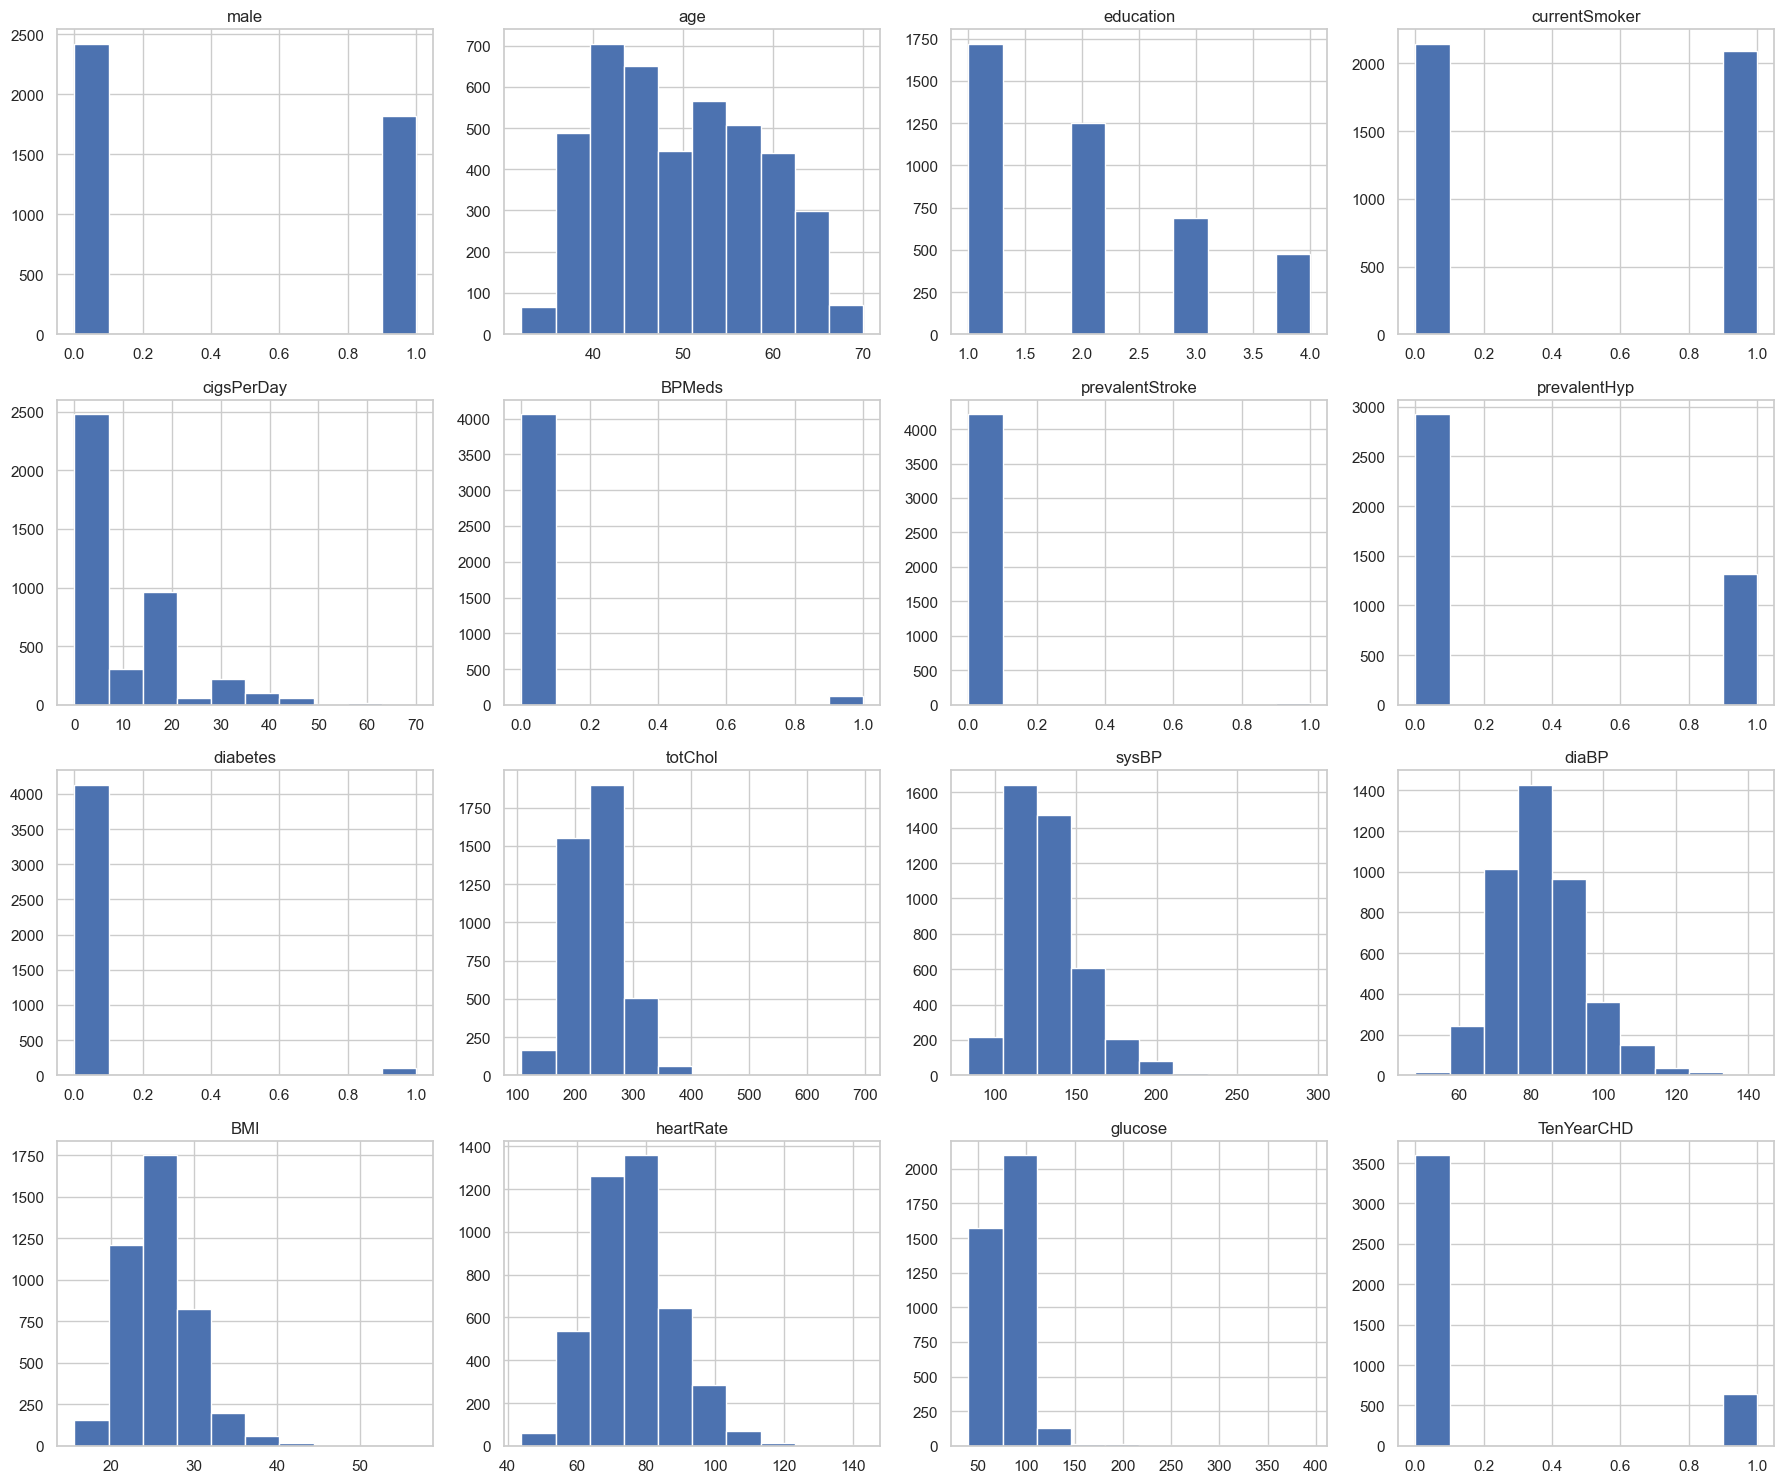

In [47]:
df.hist(figsize=(18,15))

plt.tight_layout()

plt.show()

### Boxplots

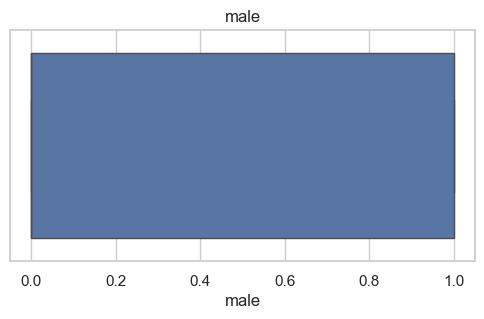

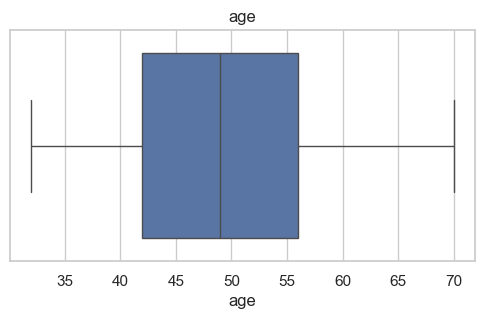

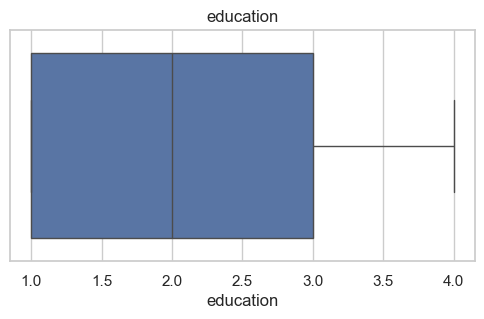

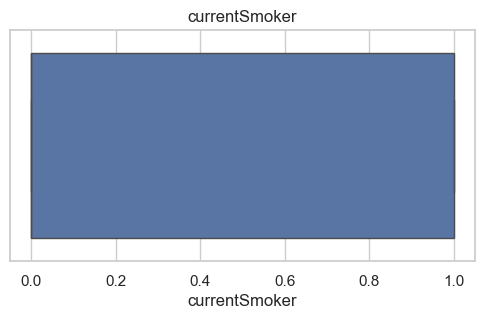

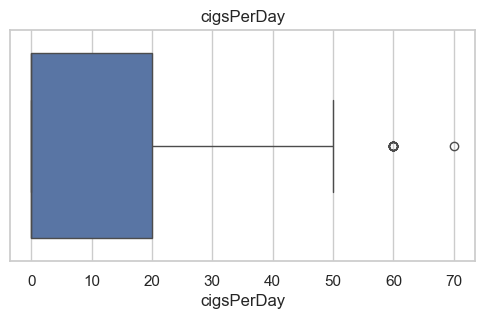

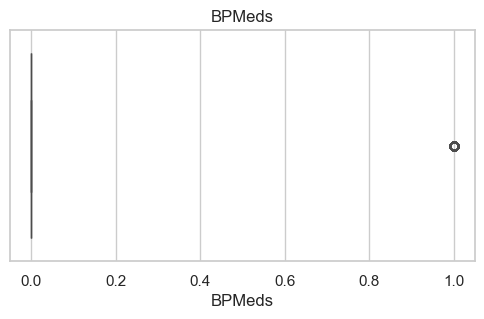

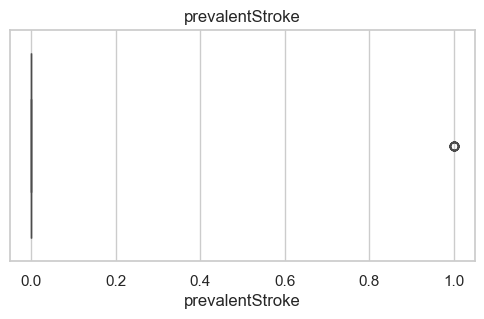

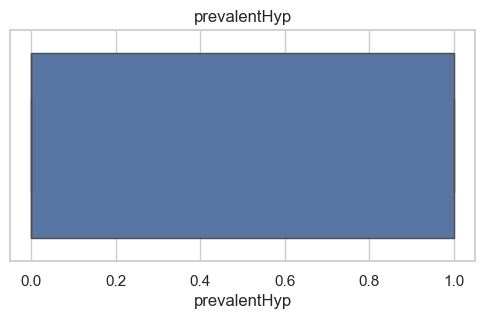

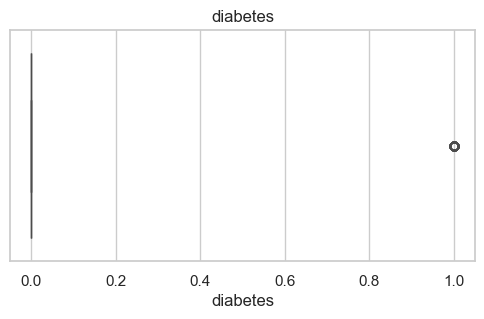

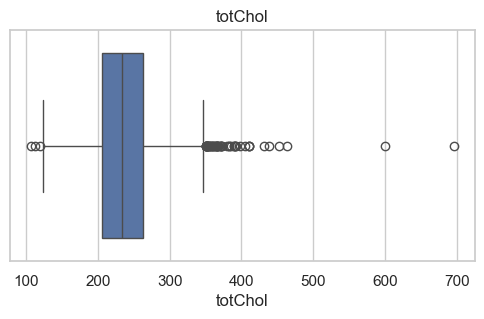

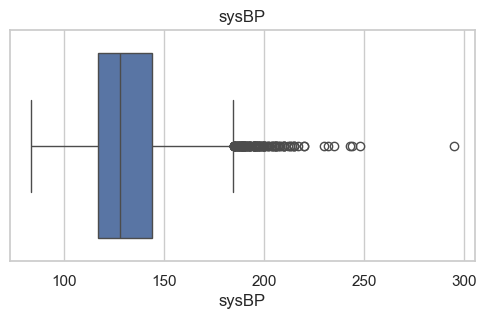

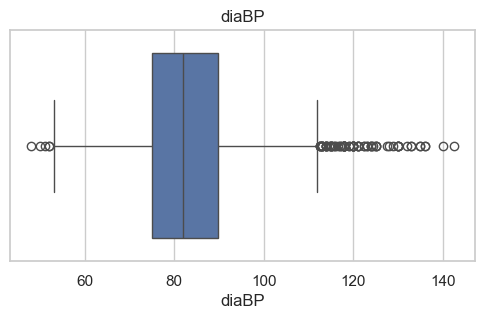

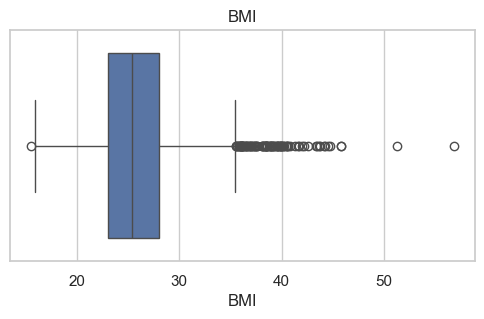

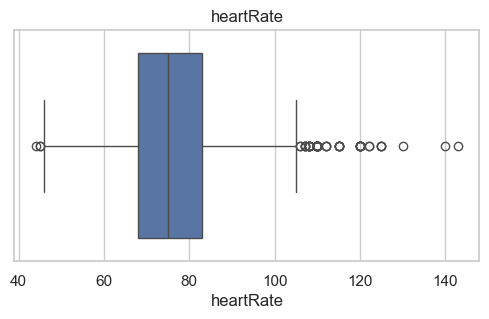

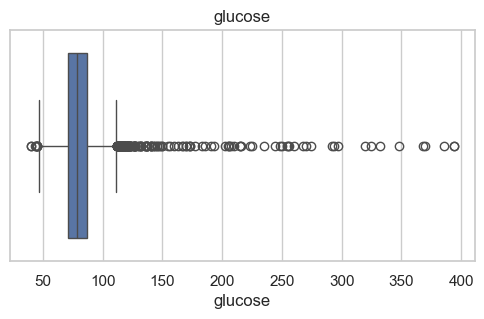

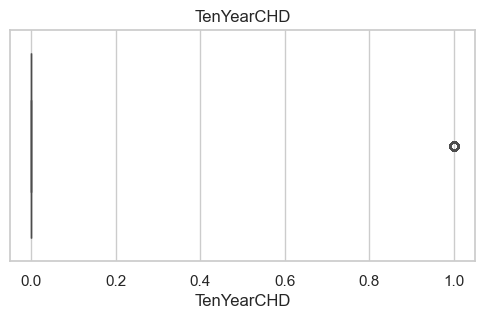

In [48]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

### Correlation Matrix

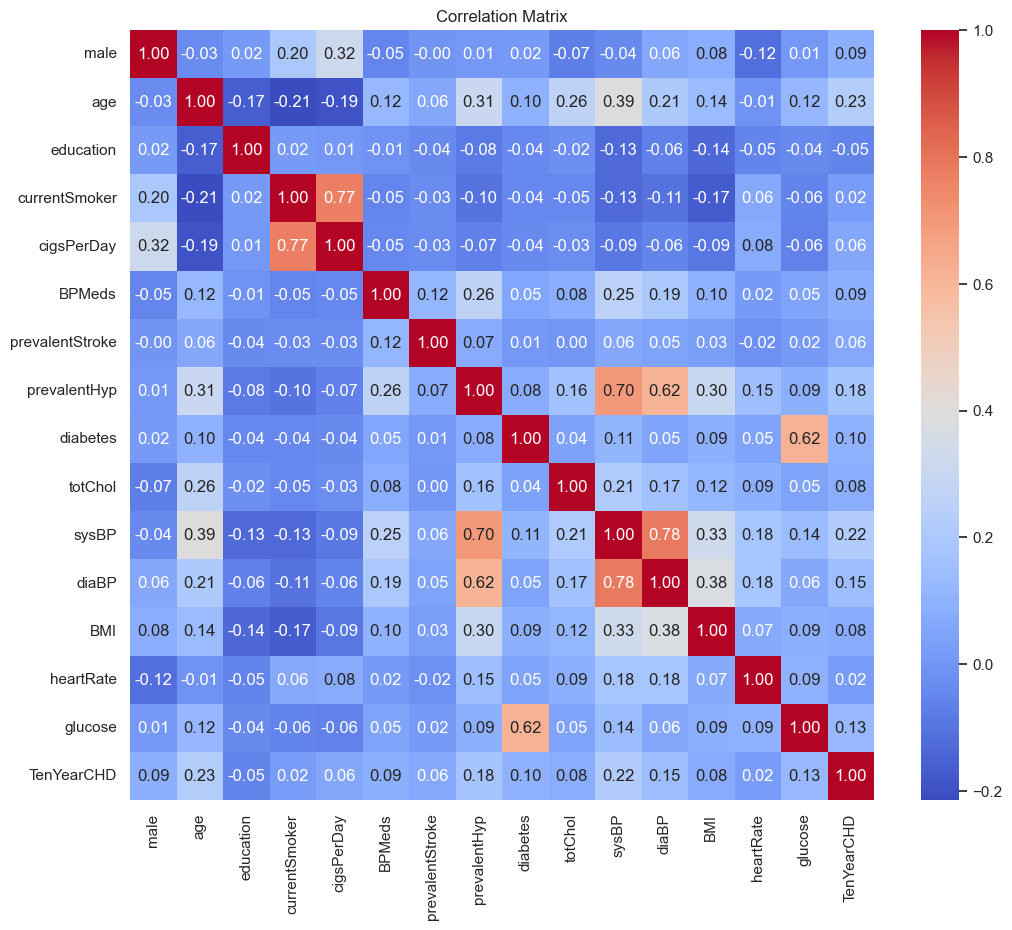

In [49]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

### Correlation with Target

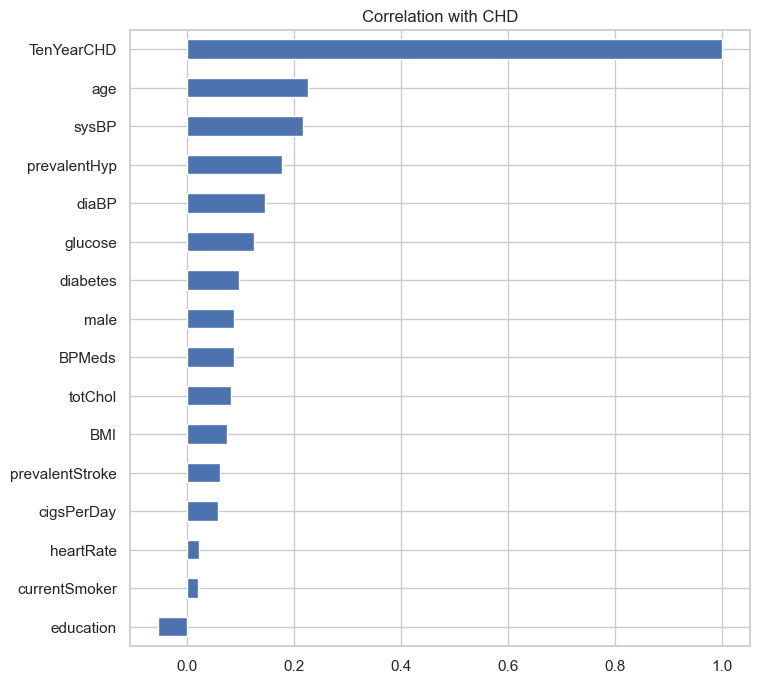

In [50]:
corr["TenYearCHD"].sort_values().plot(
    kind="barh",
    figsize=(8,8)
)

plt.title("Correlation with CHD")

plt.show()

### Feature Distribution by Target (AGE)

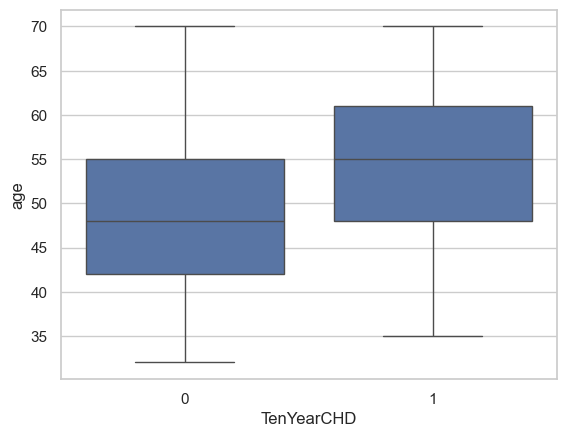

In [51]:
sns.boxplot(
    data=df,
    x="TenYearCHD",
    y="age"
)

plt.show()

### Class Balance

In [52]:
df["TenYearCHD"].value_counts(normalize=True)*100

TenYearCHD
0    84.804153
1    15.195847
Name: proportion, dtype: float64